# B-spline feature (M7)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
results_path = "/zhome/d0/a/221493/thesis/results/diffusion_cf/50/0.025/cf_results.csv"
# Load results
results_df = pd.read_csv(results_path)  
results_df

# rename column original_path to path
results_df.rename(columns={'original_path': 'path'}, inplace=True)


In [54]:
# Get the fold data
folds = [0, 1, 2, 3, 4]

fold_example_path = '/zhome/d0/a/221493/thesis/results/C2_diffusion/effusion/cv_results/cf_1/fold_0_predictions.csv'

full_diffusion_df = pd.DataFrame()
for fold in folds:
    fold_path = f'/zhome/d0/a/221493/thesis/results/C2_diffusion/effusion/cv_results/cf_1/fold_{fold}_predictions.csv'
    fold_df = pd.read_csv(fold_path)
    # append to full diffusion df
    full_diffusion_df = pd.concat([full_diffusion_df, fold_df], ignore_index=True)
    print(f"Fold {fold} data:")
    print(fold_df.head())
print(full_diffusion_df.head())

Fold 0 data:
                                                path  effusion_prob  \
0  CheXpert-v1.0-small/train/patient00157/study1/...       0.922361   
1  CheXpert-v1.0-small/train/patient00314/study18...       0.223596   
2  CheXpert-v1.0-small/train/patient00372/study4/...       0.984681   
3  CheXpert-v1.0-small/train/patient00551/study1/...       0.157196   
4  CheXpert-v1.0-small/train/patient01021/study1/...       0.025052   

   effusion_true     emb_0     emb_1     emb_2     emb_3     emb_4     emb_5  \
0            1.0 -0.001189 -0.003648  0.005156  0.003416 -0.050322  0.294127   
1            0.0 -0.001197 -0.000761  0.004916  0.004250 -0.028453 -0.100406   
2            1.0 -0.001219 -0.001071  0.004088  0.005729  0.067767  0.291900   
3            0.0 -0.001184 -0.000936  0.002150  0.004321 -0.013667  0.426885   
4            0.0 -0.001179 -0.001324  0.001965  0.004077 -0.182638  0.080132   

      emb_6  ...  MLP_B2_prob  MLP_B3_prob  MLP_B4_prob  MLP_B5_prob  \
0 -0.00

In [56]:
full_diffusion_df

,path,effusion_prob,effusion_true,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,MLP_B2_prob,MLP_B3_prob,MLP_B4_prob,MLP_B5_prob,MLP_M1_prob,MLP_M2_prob,MLP_M3_prob,MLP_M4_prob,MLP_M5_prob,MLP_M6_prob
0,CheXpert-v1.0-small/train/patient00157/study1/...,0.922361,1.0,-0.001189,-0.003648,0.005156,0.003416,-0.050322,0.294127,-0.001320,...,0.538455,0.733779,0.643111,0.688826,0.635655,0.838591,0.968729,0.724927,0.936635,0.862484
1,CheXpert-v1.0-small/train/patient00314/study18...,0.223596,0.0,-0.001197,-0.000761,0.004916,0.004250,-0.028453,-0.100406,-0.001259,...,0.705625,0.737623,0.661830,0.644735,0.774792,0.719957,0.807709,0.773311,0.536510,0.803024
2,CheXpert-v1.0-small/train/patient00372/study4/...,0.984681,1.0,-0.001219,-0.001071,0.004088,0.005729,0.067767,0.291900,-0.001305,...,0.596611,0.998057,0.713244,0.920406,0.801126,0.958744,0.984070,0.937201,0.999964,0.837878
3,CheXpert-v1.0-small/train/patient00551/study1/...,0.157196,0.0,-0.001184,-0.000936,0.002150,0.004321,-0.013667,0.426885,-0.001266,...,0.720199,0.800057,0.905043,0.613413,0.587508,0.904776,0.893199,0.877583,0.575413,0.906759
4,CheXpert-v1.0-small/train/patient01021/study1/...,0.025052,0.0,-0.001179,-0.001324,0.001965,0.004077,-0.182638,0.080132,-0.001313,...,0.798697,0.917389,0.964931,0.825912,0.695676,0.927053,0.985728,0.944570,0.977828,0.958400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,CheXpert-v1.0-small/train/patient45167/study3/...,0.992438,1.0,-0.001189,-0.001736,0.004809,0.006045,0.087896,0.442013,-0.001300,...,0.838502,0.990810,0.772539,0.885164,0.941309,0.615635,0.956994,0.892635,0.999840,0.919249
996,CheXpert-v1.0-small/train/patient45726/study1/...,0.007680,0.0,-0.001161,-0.001394,0.004972,0.007664,-0.097497,0.056949,-0.001284,...,0.678142,0.932923,0.593270,0.626499,0.609663,0.451241,0.772279,0.889213,0.960072,0.795608
997,CheXpert-v1.0-small/train/patient45802/study2/...,0.976592,1.0,-0.001218,-0.002164,0.004609,0.005953,0.032161,0.580246,-0.001260,...,0.570417,0.976960,0.674918,0.900762,0.691513,0.625310,0.731524,0.787912,0.999999,0.858250
998,CheXpert-v1.0-small/train/patient46120/study2/...,0.856980,1.0,-0.001204,-0.003298,0.004912,0.003828,0.034241,0.303678,-0.001324,...,0.876047,0.777787,0.785483,0.730954,0.811401,0.800760,0.994578,0.822163,0.999928,0.987032


In [58]:
# Merge the dataframes on the common identifier (assuming 'path' is the common column)
merged_df = pd.merge(full_diffusion_df, results_df, on='path', how='inner')

# Print how many wer ein each and in the new one
print(f"Full diffusion data: {len(full_diffusion_df)} rows")
print(f"Results data: {len(results_df)} rows")
print(f"Merged data: {len(merged_df)} rows")

Full diffusion data: 1000 rows
Results data: 80 rows
Merged data: 3 rows


In [59]:
merged_df

,path,effusion_prob,effusion_true,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,MLP_M5_prob,MLP_M6_prob,original_prob,cf_prob_y,true_label,original_pred,correct_y,cf_pred,flip_achieved,intermediate_probs
0,CheXpert-v1.0-small/train/patient12228/study3/...,0.010469,0.0,-0.001133,-0.002268,0.003528,0.003517,-0.206096,0.038283,-0.001318,...,0.999233,0.868487,0.010469,0.902019,0,0,1,1,True,"[(50, 0.23065650463104248), (49, 0.24484439194..."
1,CheXpert-v1.0-small/train/patient12175/study10...,0.933370,0.0,-0.001204,-0.001112,0.003646,0.001766,0.097516,0.733323,-0.001342,...,0.993931,0.818547,0.933370,0.174967,0,1,0,0,True,"[(50, 0.2901712656021118), (49, 0.260691642761..."
2,CheXpert-v1.0-small/train/patient46454/study2/...,0.447510,1.0,-0.001202,-0.000803,0.002616,0.003558,-0.053115,0.115401,-0.001334,...,0.735055,0.953950,0.447510,0.987836,1,0,0,1,True,"[(50, 0.3342212736606598), (49, 0.345979720354..."


### Extract bspline features

In [18]:
import ast
import numpy as np
import pandas as pd
from scipy.interpolate import make_lsq_spline

def parse_intermediate_probs(raw_string):
    """
    Parse the string representation of [(t, prob), ...] into a sorted array of probs.
    Sorts by t descending (T_start → 1) to ensure consistent ordering.
    """
    tuples = ast.literal_eval(raw_string)
    tuples_sorted = sorted(tuples, key=lambda x: x[0], reverse=True)  # t=50 first
    return np.array([p for _, p in tuples_sorted])


def extract_bspline_features(prob_sequence, n_coeffs=5, degree=3):
    """
    Fit a least-squares B-spline to a probability trajectory.
    Returns the spline coefficients as features.
    
    n_coeffs should satisfy: n_coeffs > degree (minimum viable spline)
    With 50 timesteps and n_coeffs=5, you get a smooth summary with low risk of overfitting.
    """
    t = np.linspace(0, 1, len(prob_sequence))
    y = prob_sequence

    # Number of internal knots derived from desired coefficients
    # Relationship: n_coeffs = n_internal_knots + degree + 1
    n_internal = n_coeffs - degree - 1
    
    internal_knots = np.linspace(0, 1, n_internal + 2)[1:-1]
    knots = np.concatenate([
        np.repeat(0.0, degree + 1),
        internal_knots,
        np.repeat(1.0, degree + 1)
    ])

    spline = make_lsq_spline(t, y, knots, k=degree)
    return spline.c[:n_coeffs]

In [19]:
# ── Parse and extract ─────────────────────────────────────────────────────────

# Step 1: parse the string column into numpy arrays
merged_df['prob_sequence'] = merged_df['intermediate_probs'].apply(parse_intermediate_probs)

# Step 2: extract spline coefficients for each row
N_COEFFS = 5  # start here — you can experiment with 4-7

bspline_df = merged_df['prob_sequence'].apply(
    lambda seq: pd.Series(
        extract_bspline_features(seq, n_coeffs=N_COEFFS),
        index=[f'bspline_{i}' for i in range(N_COEFFS)]
    )
)

print(bspline_df.head())
print(f"\nShape: {bspline_df.shape}")

   bspline_0  bspline_1  bspline_2  bspline_3  bspline_4
0   0.219370   0.547525   1.007041   0.854446   0.188507
1   0.436822   0.457136   0.882624   0.908391   0.092806
2   0.332081   0.180827   0.896479   1.047024   0.965910
3   0.177780   0.187272   0.637928   0.845949   0.053115
4   0.146252   0.348854   0.548912   0.715100   0.264177

Shape: (80, 5)


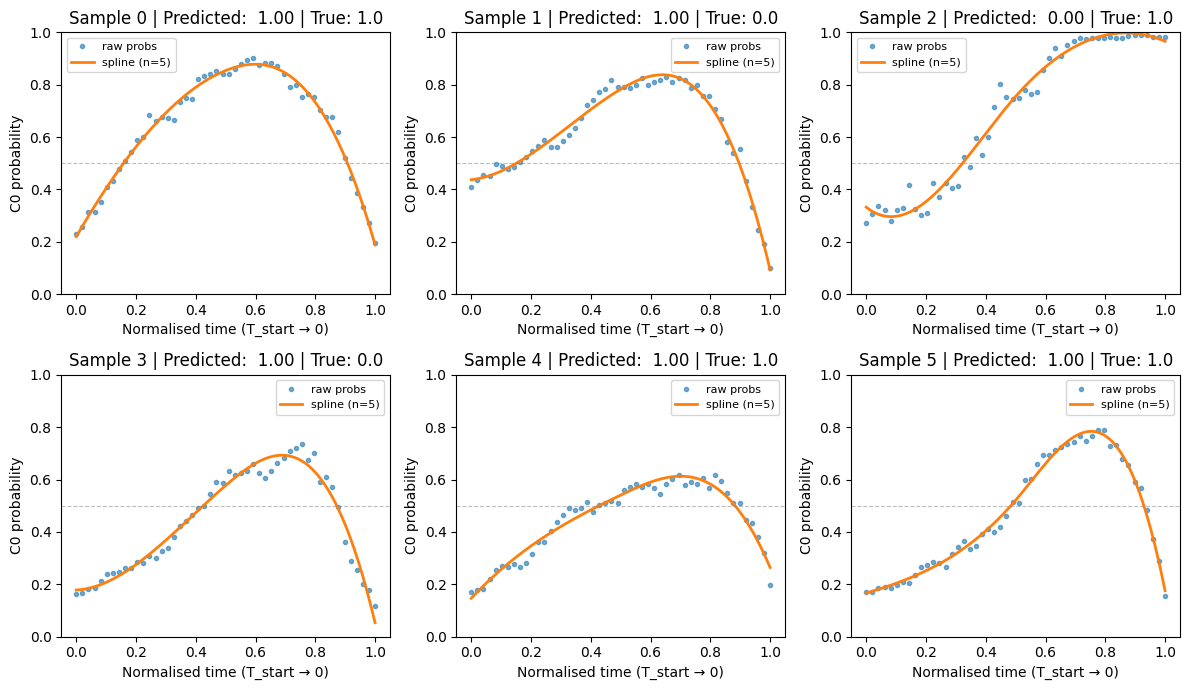

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()

for i, (idx, row) in enumerate(merged_df.head(6).iterrows()):
    
    seq = row['prob_sequence']
    t = np.linspace(0, 1, len(seq))
    
    # Reconstruct spline for plotting (refit on this row)
    coeffs = bspline_df.iloc[i].values
    n_internal = N_COEFFS - 3 - 1  # degree=3
    internal_knots = np.linspace(0, 1, n_internal + 2)[1:-1]
    knots = np.concatenate([np.repeat(0.0, 4), internal_knots, np.repeat(1.0, 4)])
    
    t_fine = np.linspace(0, 1, 200)
    spline_curve = make_lsq_spline(t, seq, knots, k=3)(t_fine)
    
    ax = axes[i]
    ax.plot(t, seq, 'o', markersize=3, alpha=0.6, label='raw probs')
    ax.plot(t_fine, spline_curve, '-', lw=2, label=f'spline (n={N_COEFFS})')
    ax.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(f"Sample {idx} | Predicted: {row['pred']: .2f} | True: {row['true']}")
    ax.set_xlabel('Normalised time (T_start → 0)')
    ax.set_ylabel('C0 probability')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [44]:
for column in merged_df.columns:
    print(column)

path
prob
true
emb_0
emb_1
emb_2
emb_3
emb_4
emb_5
emb_6
emb_7
emb_8
emb_9
emb_10
emb_11
emb_12
emb_13
emb_14
emb_15
emb_16
emb_17
emb_18
emb_19
emb_20
emb_21
emb_22
emb_23
emb_24
emb_25
emb_26
emb_27
emb_28
emb_29
emb_30
emb_31
emb_32
emb_33
emb_34
emb_35
emb_36
emb_37
emb_38
emb_39
emb_40
emb_41
emb_42
emb_43
emb_44
emb_45
emb_46
emb_47
emb_48
emb_49
emb_50
emb_51
emb_52
emb_53
emb_54
emb_55
emb_56
emb_57
emb_58
emb_59
emb_60
emb_61
emb_62
emb_63
emb_64
emb_65
emb_66
emb_67
emb_68
emb_69
emb_70
emb_71
emb_72
emb_73
emb_74
emb_75
emb_76
emb_77
emb_78
emb_79
emb_80
emb_81
emb_82
emb_83
emb_84
emb_85
emb_86
emb_87
emb_88
emb_89
emb_90
emb_91
emb_92
emb_93
emb_94
emb_95
emb_96
emb_97
emb_98
emb_99
emb_100
emb_101
emb_102
emb_103
emb_104
emb_105
emb_106
emb_107
emb_108
emb_109
emb_110
emb_111
emb_112
emb_113
emb_114
emb_115
emb_116
emb_117
emb_118
emb_119
emb_120
emb_121
emb_122
emb_123
emb_124
emb_125
emb_126
emb_127
emb_128
emb_129
emb_130
emb_131
emb_132
emb_133
emb_134
emb_135
emb_136

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import numpy as np

# ── Build feature matrix ──────────────────────────────────────────────────────

# M6 features (same as in your pipeline)
disease = 'effusion'
diff_cols = [c for c in merged_df.columns if c.startswith('delta_')]
attr_cols = [c for c in merged_df.columns 
             if c not in {'prob', 'effusion_pred', 'effusion_true',
                          'correct_x','correct_y', 'path', 'patient_id', 'cf_prob', 'cf_paths',
                          'intermediate_probs', 'prob_sequence', 'flip_achieved', 'correct'}
             and not c.startswith('delta_')
             and not c.startswith('emb_')
             and not c.startswith('bspline_')]

X_m6 = np.hstack([
    merged_df[['prob']].values,
    merged_df[diff_cols].values,
    merged_df[attr_cols].values,
    merged_df[['cf_prob']].values,
])
print(f"M6 feature names: {['prob'] + diff_cols + attr_cols + ['cf_prob']}")

X_m7 = np.hstack([X_m6, bspline_df.values])  # M7 adds bspline coefficients
print(f"M7 feature names: {['prob'] + diff_cols + attr_cols + ['cf_prob'] + list(bspline_df.columns)}")

y = merged_df['correct'].values

print(f"Samples: {len(y)} | M6 features: {X_m6.shape[1]} | M7 features: {X_m7.shape[1]}")
print(f"Class balance: {y.mean():.2f} correct")

# ── Cross-validated AUC ───────────────────────────────────────────────────────
# With only ~80 samples, CV is essential — a single train/test split is unreliable

def cv_auc(X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    aucs = []
    for train_idx, test_idx in skf.split(X, y):
        scaler = StandardScaler()
        model = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
        model.fit(scaler.fit_transform(X[train_idx]), y[train_idx])
        y_prob = model.predict_proba(scaler.transform(X[test_idx]))[:, 1]
        aucs.append(roc_auc_score(y[test_idx], y_prob))
    return np.mean(aucs), np.std(aucs)

# Fill NaNs in attribute columns (same as compute_cf_for_split does)
merged_df[attr_cols] = merged_df[attr_cols].fillna(0)
merged_df[diff_cols] = merged_df[diff_cols].fillna(0)
merged_df[['cf_prob']] = merged_df[['cf_prob']].fillna(0)

m6_mean, m6_std = cv_auc(X_m6, y)
m7_mean, m7_std = cv_auc(X_m7, y)

print(f"\nM6 AUC: {m6_mean:.3f} ± {m6_std:.3f}")
print(f"M7 AUC: {m7_mean:.3f} ± {m7_std:.3f}")

M6 feature names: ['prob', 'true', 'pred', 'margin', 'age_pred', 'sex_male', 'sex_female', 'race_white', 'race_black', 'race_asian', 'Left Clavicle_area_pixels', 'Left Clavicle_bbox_width', 'Left Clavicle_bbox_height', 'Left Clavicle_bbox_ratio', 'Left Clavicle_perimeter', 'Left Clavicle_original_shape2D_Elongation', 'Left Clavicle_original_shape2D_MajorAxisLength', 'Left Clavicle_original_shape2D_MaximumDiameter', 'Left Clavicle_original_shape2D_MeshSurface', 'Left Clavicle_original_shape2D_MinorAxisLength', 'Left Clavicle_original_shape2D_Perimeter', 'Left Clavicle_original_shape2D_PerimeterSurfaceRatio', 'Left Clavicle_original_shape2D_PixelSurface', 'Left Clavicle_original_shape2D_Sphericity', 'Left Clavicle_original_firstorder_10Percentile', 'Left Clavicle_original_firstorder_90Percentile', 'Left Clavicle_original_firstorder_Energy', 'Left Clavicle_original_firstorder_Entropy', 'Left Clavicle_original_firstorder_InterquartileRange', 'Left Clavicle_original_firstorder_Kurtosis', 'L

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [50]:
# Check each column in attr_cols for NaNs
nan_cols = [c for c in attr_cols if merged_df[c].isna().any()]
print("Columns with NaNs in attr_cols:", nan_cols)

# Also check dtypes — non-numeric columns produce NaN when cast to float
non_numeric = [c for c in attr_cols if not pd.api.types.is_numeric_dtype(merged_df[c])]
print("Non-numeric columns in attr_cols:", non_numeric)

Columns with NaNs in attr_cols: []
Non-numeric columns in attr_cols: []


In [51]:
# Check each component of X_m6 separately, after rebuilding
components = {
    'prob':    merged_df[['prob']].values,
    'diff':    merged_df[diff_cols].values,
    'attr':    merged_df[attr_cols].values,
    'cf_prob': merged_df[['cf_prob']].values,
}

for name, arr in components.items():
    print(f"NaNs in {name}: {np.isnan(arr).sum()} | dtype: {arr.dtype} | shape: {arr.shape}")

NaNs in prob: 0 | dtype: float64 | shape: (80, 1)
NaNs in diff: 0 | dtype: float64 | shape: (80, 0)
NaNs in attr: 0 | dtype: float64 | shape: (80, 461)
NaNs in cf_prob: 0 | dtype: float64 | shape: (80, 1)


In [32]:
# Find which attr columns are not numeric
non_numeric = [c for c in attr_cols if not pd.api.types.is_numeric_dtype(merged_df[c])]
print("Non-numeric attr columns:", non_numeric)

Non-numeric attr columns: []


In [33]:
print(merged_df[attr_cols].dtypes.value_counts())

float64    458
int64        6
bool         1
Name: count, dtype: int64


In [34]:
bool_cols = [c for c in attr_cols if merged_df[c].dtype == bool]
print("Bool columns:", bool_cols)

# Exclude from attr_cols
attr_cols = [c for c in attr_cols if merged_df[c].dtype != bool]

Bool columns: ['flip_achieved']
